# Does "carry" really pay off everywhere? 🌍💰
### FX, bonds, dividend stocks, commodities — one signal, four markets, and a combo that turns out to add up to **nothing**

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Crashes_everywhere_at_once%3F: Busted](https://img.shields.io/badge/Crashes_everywhere_at_once%3F-Busted-8b949e?style=flat-square)

"Carry" is the simplest idea in investing: hold the thing that pays you to hold it. Borrow a low-interest currency, lend a high one, pocket the gap. Buy the dividend stock instead of the growth stock, pocket the yield. A famous 2018 paper (Koijen, Moskowitz, Pedersen & Vrugt) argued this isn't just an FX trick — the same logic pays off in bonds, equities and commodities too, and because the four markets barely talk to each other, blending them should give you a smoother, *more reliable* payday than any one alone.

We rebuilt all four sleeves on free data and blended them. Here's what happened.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the bootstrap and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Four *static* baskets (composition fixed from each market's textbook carry classification, never re-fit to the data — like reading a public calendar, this has zero look-ahead), 2007-07 → 2026-06, 19 years including the 2008 and 2020 crashes. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from carry_everywhere import data as dt, strategy as st

HAVE_REAL = dt.have_real()
if HAVE_REAL:
    CLOSES = dt.load_real()
    MRET = dt.monthly_returns(CLOSES)
    SL = st.all_sleeves(MRET)
    CB = st.combo(SL)
else:
    CLOSES = MRET = SL = CB = None
print("real cache present:", HAVE_REAL, "| sleeve-months:", (0 if SL is None else len(SL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2007-07', 'end': '2026-06', 'n': 228, 'fp': 'ed7c280e84fe', 'sleeves': {'FX': {'ann': -0.48, 'vol': 10.39, 'sharpe': -0.05, 't': -0.2, 'skew': -0.74, 'maxdd': -39.6}, 'BOND': {'ann': 1.71, 'vol': 5.62, 'sharpe': 0.3, 't': 1.33, 'skew': 0.23, 'maxdd': -20.82}, 'EQ': {'ann': -3.9, 'vol': 11.05, 'sharpe': -0.35, 't': -1.44, 'skew': -0.07, 'maxdd': -60.71}, 'CMD': {'ann': 2.41, 'vol': 7.14, 'sharpe': 0.34, 't': 1.39, 'skew': 0.75, 'maxdd': -23.99}}, 'corr': {('FX', 'BOND'): -0.24, ('FX', 'EQ'): -0.11, ('FX', 'CMD'): -0.26, ('BOND', 'EQ'): -0.06, ('BOND', 'CMD'): 0.3, ('EQ', 'CMD'): -0.05}, 'combo_ann': -0.07, 'combo_vol': 3.79, 'combo_sharpe': -0.02, 'combo_t': -0.08, 'combo_skew': 0.01, 'combo_maxdd': -18.51, 'combo_ci': (-0.45, 0.43), 'ivw': {'FX': 0.191, 'BOND': 0.352, 'EQ': 0.179, 'CMD': 0.277}, 'ivw_ann': 0.48, 'ivw_sharpe': 0.14, 'ivw_t': 0.62, 'ex_eq_ann': 1.21, 'ex_eq_sharpe': 0.3, 'ex_eq_t': 1.41, 'turnover': {'FX': 0.048, 'BOND': 0.018, 'EQ': 0.074, 'CMD': 0.091}, 'net5_ann': -0.26, 'net5_sharpe': -0.07, 'net5_t': -0.31, 'net10_ann': -0.3, 'net10_sharpe': -0.08, 'net10_t': -0.35, 'gfc': {'combo': -0.96, 'other': -0.001, 'FX': -27.09, 'BOND': 4.69, 'EQ': 13.66, 'CMD': 8.43}, 'covid': {'combo': 2.26, 'other': -0.016, 'FX': -4.62, 'BOND': 4.62, 'EQ': -10.68, 'CMD': 20.87}, 'syn_null_mean': -0.15, 'syn_null_sd': 1.13, 'syn_null_fire': 1, 'syn_null_seeds': 20, 'syn_planted_t': 2.5, 'syn_planted_sharpe': 0.56, 'syn_planted_ann': 2.06, 'syn_crash_t': -0.06, 'syn_crash_sharpe': -0.01, 'syn_crash_skew': -2.84}


real cache present: True | sleeve-months: 228


## The answer first

| Question | Answer |
|---|---|
| Does each carry sleeve pay on its own? | **Not convincingly.** Bond carry (+1.7%/yr) and commodity carry (+2.4%/yr) lean positive but aren't statistically solid; FX carry is flat (-0.5%/yr); equity carry is outright negative (-3.9%/yr). |
| Does blending the four fix it? | **No.** The equal-weight combo earns **-0.07%/yr** — statistically indistinguishable from zero. Diversifying four so-so ingredients doesn't bake a cake. |
| Does it at least crash on cue, proving it's "real risk you're paid to bear"? | **No — and that's the interesting part.** In 2008 the FX leg cratered **-27.1%** while the other three sleeves were solidly *positive*. In 2020 the equity leg cratered **-10.7%** while the commodity leg *spiked* **+20.9%**. The crashes never line up. |
| So what actually happened? | On this tape, there's simply no premium there to protect — combining four legs that individually miss the bar just gives you a quieter zero. |

> Four markets, one idea, zero payoff — but for an oddly reassuring reason: they don't fall apart together either.

## 1 · The claim

> *"In every asset class — currencies, bonds, stocks, commodities — the asset that pays you more to hold it (all else equal) tends to keep paying you more. Carry works everywhere, and because the carry premium in one market is basically unrelated to carry in another, you can diversify across them and end up with a smoother, more dependable return than any single carry trade offers."*

It's the kind of claim that sounds almost too tidy — the same intuition, four different costumes. Koijen, Moskowitz, Pedersen & Vrugt formalized it in 2018 with decades of institutional data. We're asking whether it survives a rebuild on the free data anyone can pull today.

## 2 · So what?

If true, this is close to a holy grail for a small allocator: a genuinely diversifying source of return, built from instruments anyone can trade (ETFs and spot FX, no exotic derivatives required), with a story that doesn't depend on correctly forecasting where any market is *headed* — only on collecting what it already pays you to wait. That's the pitch behind entire multi-strategy "carry fund" products. So: does each leg actually pay, does blending them help, and does the whole thing crash exactly when a risk premium is supposed to?

## 3 · How would we even know?

- **Four fixed baskets**, one per asset class, built from each market's textbook high-carry vs low-carry pairing — never re-fit to the data:
  - **FX**: long AUD+NZD (classic high-yielders), short JPY+CHF (classic funders)
  - **Bond**: long IEF (7-10y Treasuries), short SHY (1-3y) — the term-spread trade
  - **Equity**: long VYM (high dividend yield), short VUG (growth, low yield)
  - **Commodity**: long DBC (a roll-optimized broad basket), short GSG (a naive-roll basket) — isolating the roll-yield component
- **The test.** Does each sleeve earn a statistically real premium (a *t*-stat clearing 2)? Does an equal blend of the four beat any one of them? And do the legs really unravel together in **2008 GFC** and **2020 COVID** — the two windows the carry-crash story is built on?

## 4 · The teardown — let's actually look

**First, the four sleeves on their own.**

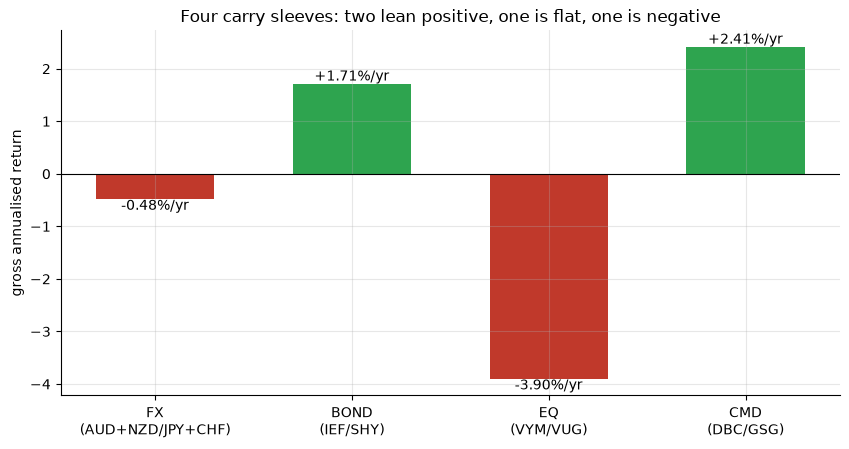

{'FX': np.float64(-0.48), 'BOND': np.float64(1.71), 'EQ': np.float64(-3.9), 'CMD': np.float64(2.41)}


In [2]:
if HAVE_REAL:
    anns = {c: SL[c].mean()*12*100 for c in SL.columns}
else:
    anns = {k: v['ann'] for k, v in R['sleeves'].items()}
labels = ['FX\n(AUD+NZD/JPY+CHF)','BOND\n(IEF/SHY)','EQ\n(VYM/VUG)','CMD\n(DBC/GSG)']
vals = [anns[k] for k in ['FX','BOND','EQ','CMD']]
cols = [GREEN if v>0 else RED for v in vals]
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.bar(labels, vals, color=cols, width=.6)
for i,v in enumerate(vals): ax.annotate(f'{v:+.2f}%/yr',(i,v),ha='center',
    va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('gross annualised return')
ax.set_title('Four carry sleeves: two lean positive, one is flat, one is negative')
plt.tight_layout(); plt.show()
print({k: round(v,2) for k,v in anns.items()})

Bond and commodity carry lean positive (**+1.71%/yr** and **+2.41%/yr**) but — spoiler for the quants notebook — neither clears the statistical bar alone. FX carry, the textbook trade, is roughly flat (**-0.48%/yr**) over a period dominated by the post-2008 near-zero-rate years. Equity carry is the surprise laggard (**-3.90%/yr**) — dividend stocks (VYM) lost outright to growth stocks (VUG) through the biggest mega-cap tech bull market in a generation, and our simple proxy can't tell that apart from a genuine carry failure.

**Now, the blend.** Does averaging the four help?

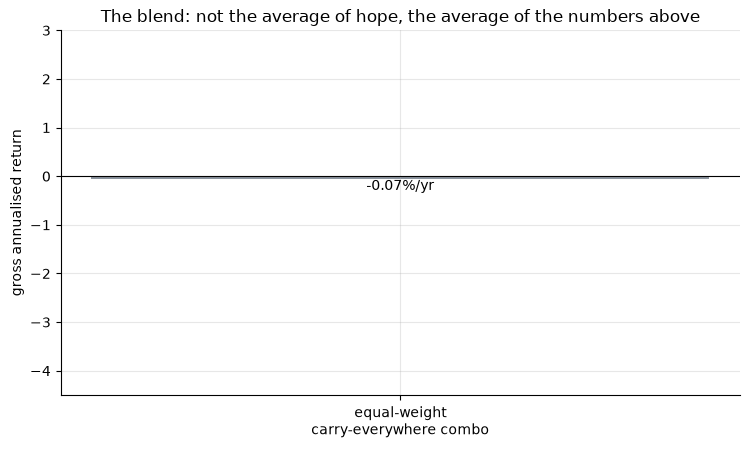

combo: -0.07%/yr


In [3]:
if HAVE_REAL:
    c_ann = CB.mean()*12*100
else:
    c_ann = R['combo_ann']
fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.bar(['equal-weight\ncarry-everywhere combo'], [c_ann], color=GREY, width=.45)
ax.annotate(f'{c_ann:+.2f}%/yr', (0, c_ann), ha='center',
    va='top' if c_ann<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylim(-4.5, 3.0)
ax.set_ylabel('gross annualised return')
ax.set_title('The blend: not the average of hope, the average of the numbers above')
plt.tight_layout(); plt.show()
print(f'combo: {c_ann:+.2f}%/yr')

**-0.07%/yr.** Essentially nothing. The quants notebook shows the combo's *t*-stat is **-0.08** — you cannot even confidently say the sign is right, let alone bank the number. Blending four ingredients where two are weak, one is flat and one is negative doesn't average up to a premium; it averages toward whatever the four actually summed to, which here is close to zero.

**Finally, the crash test.** If carry really is "a premium for selling insurance," the payoff should evaporate — hard — exactly when markets panic. Let's check both 2008 and 2020:

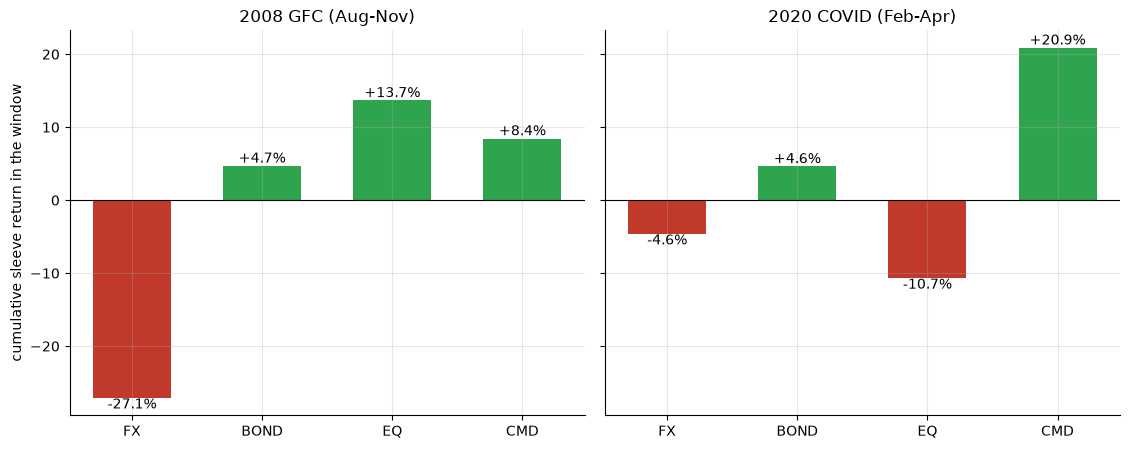

GFC: {'FX': -27.094985881843105, 'BOND': 4.688435979832839, 'EQ': 13.662636811319008, 'CMD': 8.434051540495634}
COVID: {'FX': -4.618721940426218, 'BOND': 4.618115907101683, 'EQ': -10.681683847071621, 'CMD': 20.868618787246106}


In [4]:
if HAVE_REAL:
    gfc = {c: st.crisis_stats(SL[c], dt.GFC_WINDOW)['cum_return_pct'] for c in SL.columns}
    covid = {c: st.crisis_stats(SL[c], dt.COVID_WINDOW)['cum_return_pct'] for c in SL.columns}
else:
    gfc = {k: R['gfc'][k] for k in ['FX','BOND','EQ','CMD']}
    covid = {k: R['covid'][k] for k in ['FX','BOND','EQ','CMD']}
keys = ['FX','BOND','EQ','CMD']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.6), sharey=True)
for ax, d, title in [(a1, gfc, '2008 GFC (Aug-Nov)'), (a2, covid, '2020 COVID (Feb-Apr)')]:
    vals = [d[k] for k in keys]
    cols = [GREEN if v>0 else RED for v in vals]
    ax.bar(keys, vals, color=cols, width=.6)
    for i,v in enumerate(vals): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',
        va='top' if v<0 else 'bottom')
    ax.axhline(0, c='k', lw=.8); ax.set_title(title)
a1.set_ylabel('cumulative sleeve return in the window')
plt.tight_layout(); plt.show()
print('GFC:', gfc); print('COVID:', covid)

They don't move together. In 2008, FX carry cratered **-27.1%** while the other three sleeves were comfortably positive. In 2020, equity carry cratered **-10.7%** while commodity carry *spiked* **+20.9%** (oil's April-2020 negative-price shock hit the naive-roll commodity index far harder than the roll-optimized one, blowing the spread wide open in the *carry basket's* favor). The result: the **combo** was roughly flat in 2008 (**-0.96%**) and actually up in 2020 (**+2.26%**). The "synchronized carry crash" of finance folklore just doesn't show up here — the legs crash on their own schedules, and that happens to cancel out.

## 5 · The verdict

- **Signal — None.** Four legs, none clearing a statistical bar alone, and an equal-weight blend of **-0.07%/yr** that is indistinguishable from zero. Diversifying four so-so ingredients gives you a quieter zero, not a premium.
- **Tradability — Mirage.** There's nothing to size, and costs push the already-flat number slightly negative.
- **"Crashes everywhere at once?" — Busted.** In both 2008 and 2020 the legs moved in *different* directions, at *different* times, cancelling rather than compounding. That's a genuinely interesting (if quiet) finding: the diversification logic KMPV describe held up structurally — it just had nothing positive to protect.

## 6 · Going further 🚪

- **This is a proxy problem as much as a signal problem.** Real KMPV-style carry uses live deposit rates, actual futures curves and dozens of instruments per asset class, re-ranked monthly. Our four static 2-vs-2 baskets on free ETF/spot data are a much coarser instrument — a fair, honest rebuild, but not the original paper's own (richer) test.
- **The equity leg is the weak link worth re-testing.** Dividend yield conflates carry with the value factor; a cleaner carry proxy (e.g. options-implied dividend swaps, or short-rate-adjusted earnings yield) might separate the two.
- **Sibling studies:** [364-fx-carry-trade](../../364-fx-carry-trade/) does the FX leg properly on its own; [612-em-debt-carry](../../612-em-debt-carry/) does one packaged-carry sleeve in depth; [638-value-momentum-everywhere](../../638-value-momentum-everywhere/) runs the identical multi-sleeve combo architecture for a *different* signal pair — and lands on the same kind of statistical zero.

*Think a richer carry proxy would flip this? Show a combo that clears *t* ≥ 2 net of costs on free data, and we'll rerun the teardown.*